In [2]:
import pandas_datareader as pdr

In [3]:
key = "e65bd272bd2499873c41141f78b2e8c54bd94272"
df = pdr.get_data_tiingo('AAPL', api_key= key)

/Users/nipuntewari/miniforge3/envs/tf_env/lib/python3.10/site-packages/pandas_datareader/tiingo.py:234: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  return pd.concat(dfs, self._concat_axis)


In [4]:
df.to_csv('./AAPL.csv')

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('./AAPL.csv')

In [8]:
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2017-06-02 00:00:00+00:00,155.45,155.45,152.89,153.58,27285861,36.783136,36.783136,36.177379,36.340650,109143444,0.0,1.0
1,AAPL,2017-06-05 00:00:00+00:00,153.93,154.45,153.46,154.34,24803858,36.423468,36.546512,36.312255,36.520483,99215432,0.0,1.0
2,AAPL,2017-06-06 00:00:00+00:00,154.45,155.81,153.78,153.90,26249630,36.546512,36.868320,36.387974,36.416369,104998520,0.0,1.0
3,AAPL,2017-06-07 00:00:00+00:00,155.37,155.98,154.48,155.02,20678772,36.764206,36.908546,36.553611,36.681388,82715088,0.0,1.0
4,AAPL,2017-06-08 00:00:00+00:00,154.99,155.54,154.40,155.25,20771367,36.674289,36.804432,36.534681,36.735811,83085468,0.0,1.0


In [9]:
df2 = df.reset_index()['close']

In [10]:
df2.head()

0    155.45
1    153.93
2    154.45
3    155.37
4    154.99
Name: close, dtype: float64

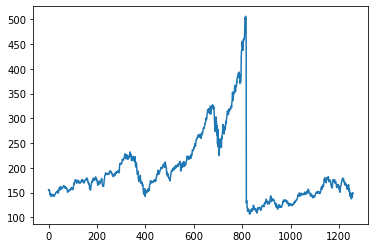

In [11]:
import matplotlib.pyplot as plt
plt.plot(df2)

In [12]:
# LSTM is sensitive to the scale of data. so we need to normalize

In [13]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [14]:
scaler = MinMaxScaler(feature_range= (0, 1))
df2 = scaler.fit_transform(np.array(df2).reshape(-1, 1)) 

In [15]:
df2.shape

(1258, 1)

In [16]:
#splitting dataset into train test
training_size = int(len(df2)*0.7)
test_size = len(df2) - training_size
train_data, test_data = df2[:training_size, :], df2[training_size:, :]

In [17]:
train_data.shape, test_data.shape

((880, 1), (378, 1))

In [19]:
def create_dataset(dataset, time_step= 1):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

In [20]:
time_step = 30
X_train, y_train = create_dataset(train_data, time_step= time_step)
X_test, y_test = create_dataset(test_data, time_step= time_step)

In [21]:
X_train.shape, X_test.shape

((849, 30), (347, 30))

In [22]:
# reshape input to [samples, time_steps, features] format requried for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [27]:
# create model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [30]:
model = Sequential()
model.add(LSTM(50, return_sequences= True, input_shape= (30, 1)))
model.add(LSTM(50, return_sequences= True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss= 'mean_squared_error', optimizer= 'adam')

In [31]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 30, 50)            10400     
                                                                 
 lstm_4 (LSTM)               (None, 30, 50)            20200     
                                                                 
 lstm_5 (LSTM)               (None, 50)                20200     
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 50,851
Trainable params: 50,851
Non-trainable params: 0
_________________________________________________________________


In [33]:
model.fit(
    X_train,
    y_train,
    validation_data= (X_test, y_test),
    epochs= 100,
    batch_size= 64, 
    verbose= 1
)

Epoch 1/100


2022-06-01 13:39:33.889253: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2022-06-01 13:39:35.639937: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 13:39:35.913997: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 13:39:36.132992: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 13:39:36.199932: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 13:39:36.386568: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 13:39:36.620388: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113

14/14 [==============================] - ETA: 0s - loss: 0.0329

2022-06-01 13:39:38.344406: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 13:39:38.448596: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 13:39:38.490307: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 13:39:38.536992: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


14/14 [==============================] - 5s 122ms/step - loss: 0.0329 - val_loss: 8.7870e-04
Epoch 2/100
14/14 [==============================] - 1s 37ms/step - loss: 0.0127 - val_loss: 0.0024
Epoch 3/100
14/14 [==============================] - 0s 32ms/step - loss: 0.0085 - val_loss: 0.0011
Epoch 4/100
14/14 [==============================] - 0s 35ms/step - loss: 0.0078 - val_loss: 3.7360e-04
Epoch 5/100
14/14 [==============================] - 0s 30ms/step - loss: 0.0068 - val_loss: 8.6581e-04
Epoch 6/100
14/14 [==============================] - 0s 32ms/step - loss: 0.0061 - val_loss: 5.1298e-04
Epoch 7/100
14/14 [==============================] - 0s 29ms/step - loss: 0.0057 - val_loss: 5.6972e-04
Epoch 8/100
14/14 [==============================] - 0s 30ms/step - loss: 0.0056 - val_loss: 2.4920e-04
Epoch 9/100
14/14 [==============================] - 0s 31ms/step - loss: 0.0043 - val_loss: 3.0704e-04
Epoch 10/100
14/14 [==============================] - 0s 31ms/step - loss: 0.0061 -

In [34]:
# predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

2022-06-01 13:41:01.494266: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 13:41:01.606027: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 13:41:01.668779: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


10/27 [==========>...................] - ETA: 0s

2022-06-01 13:41:01.717634: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


11/11 [==============================] - 0s 20ms/step


In [35]:
# transform to original form
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

In [36]:
# evaluate performance
from sklearn.metrics import mean_squared_error

In [39]:
# training scores
print(f"RMSE training: {np.sqrt(mean_squared_error(y_train, train_predict))}")
print(f"RMSE testing: {np.sqrt(mean_squared_error(y_test, test_predict))}")

RMSE training: 220.07811029618003
RMSE testing: 147.5961240931242


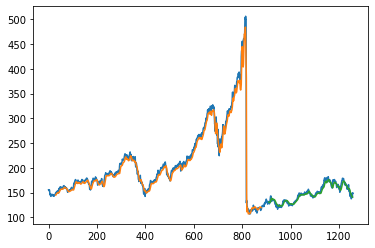

In [40]:
### Plotting 
# shift train predictions for plotting
look_back=time_step
trainPredictPlot = np.empty_like(df2)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = np.empty_like(df2)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df2)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df2))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()